In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 📦 Library Setup & Imports

This section installs required libraries and imports all dependencies needed for the image classification pipeline.

---

## 🔧 Installation

```python
!pip install -q ddgs timm scikit-learn seaborn

In [2]:
!pip install -q ddgs timm scikit-learn seaborn

import os, random, shutil, requests
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from io import BytesIO
from collections import Counter

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import timm
from ddgs import DDGS

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 42.8 MB/s eta 0:00:00


# 🔁 Reproducibility Setup

This section ensures that the experiment produces **consistent and repeatable results** across multiple runs.

---

## 🎯 Why Reproducibility Matters

Deep learning models involve randomness in:
- Weight initialization  
- Data shuffling  
- GPU computations  

Without fixing randomness, results can vary between runs.

---

## ⚙️ Setting Random Seeds

```python
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

In [3]:
# =========================
# 1. REPRODUCIBILITY
# =========================
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


# 🌐 Image Download Function

This function automatically downloads images from the web to build a custom dataset for training.

---

## ⚙️ Function Overview

```python
def download_images(query, folder, target_count):

In [4]:
# =========================
# 2. DOWNLOAD FUNCTION
# =========================
def download_images(query, folder, target_count):
    os.makedirs(folder, exist_ok=True)
    count = len(os.listdir(folder))

    with DDGS() as ddgs:
        results = ddgs.images(query, max_results=target_count*3)
        for r in results:
            try:
                url = r["image"]
                resp = requests.get(url, timeout=5)
                img = Image.open(BytesIO(resp.content)).convert("RGB")

                if min(img.size) < 100:
                    continue

                img.save(f"{folder}/{count}.jpg")
                count += 1

                if count >= target_count:
                    break
            except:
                continue

    print(f"{folder}: {count} images")

# 📥 Dataset Collection

This section uses the `download_images` function to automatically collect images for both classes: **chicken** and **duck**.

---

## 🔍 Image Queries

```python
download_images("real chicken bird photo", "raw/chicken", 100)
download_images("real chicken farm bird close up", "raw/chicken", 100)

download_images("real duck bird water", "raw/duck", 100)
download_images("wild duck bird lake", "raw/duck", 100)

In [6]:
# =========================
# 3. DOWNLOAD
# =========================
download_images("real chicken bird photo", "raw/chicken", 100)
download_images("real chicken farm bird close up", "raw/chicken", 100)

download_images("real duck bird water", "raw/duck", 100)
download_images("wild duck bird lake", "raw/duck", 100)

print("Chicken:", len(os.listdir("raw/chicken")))
print("Duck:", len(os.listdir("raw/duck")))

raw/chicken: 100 images
raw/chicken: 101 images
raw/duck: 99 images
raw/duck: 100 images
Chicken: 101
Duck: 100


# 🧹 Data Cleaning & Validation

This step ensures that all downloaded images are **valid, readable, and in a consistent format** before training.

---

## ⚙️ Function Overview

```python
def validate_and_clean(folder):

In [7]:
# =========================
# 4. CLEAN DATA
# =========================
def validate_and_clean(folder):
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        try:
            img = Image.open(path).convert("RGB")
            img.save(path)
        except:
            os.remove(path)

validate_and_clean("raw/chicken")
validate_and_clean("raw/duck")

# 🔀 Data Splitting

This step divides the dataset into **training, validation, and test sets** to enable proper model training and evaluation.

---

## ⚙️ Function Overview

```python
def split_data(src, dest):

In [8]:
# =========================
# 5. SPLIT DATA
# =========================
def split_data(src, dest):
    for cls in os.listdir(src):
        files = os.listdir(f"{src}/{cls}")
        random.shuffle(files)
        n = len(files)

        splits = {
            "train": files[:int(0.7*n)],
            "val": files[int(0.7*n):int(0.85*n)],
            "test": files[int(0.85*n):]
        }

        for split in splits:
            os.makedirs(f"{dest}/{split}/{cls}", exist_ok=True)
            for f in splits[split]:
                shutil.copy(f"{src}/{cls}/{f}", f"{dest}/{split}/{cls}/{f}")

split_data("raw", "dataset")


# 🖼️ Image Transforms & Preprocessing

This step defines how images are **preprocessed and augmented** before being fed into the model.

---

## ⚙️ Training Transforms

```python
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

In [9]:
# =========================
# 6. TRANSFORMS
# =========================
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

test_tf = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# 📦 Data Loading

This step converts the image folders into **PyTorch datasets and dataloaders** for efficient training and evaluation.

---

## 📁 Dataset Initialization

```python
data_dir = "dataset"

image_datasets = {
    x: datasets.ImageFolder(f"{data_dir}/{x}", train_tf if x=='train' else test_tf)
    for x in ['train','val','test']
}

In [10]:
# =========================
# 7. DATA LOADERS
# =========================
data_dir = "dataset"

image_datasets = {
    x: datasets.ImageFolder(f"{data_dir}/{x}", train_tf if x=='train' else test_tf)
    for x in ['train','val','test']
}

dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=32, shuffle=(x=='train'))
    for x in ['train','val','test']
}

class_names = image_datasets['train'].classes
print("Train distribution:", Counter(image_datasets['train'].targets))

Train distribution: Counter({0: 70, 1: 70})


# 👀 Visualizing Training Samples

This step displays a batch of images from the training dataset to **verify preprocessing and augmentation**.

---

## ⚙️ Function Overview

```python
def show_batch(loader):

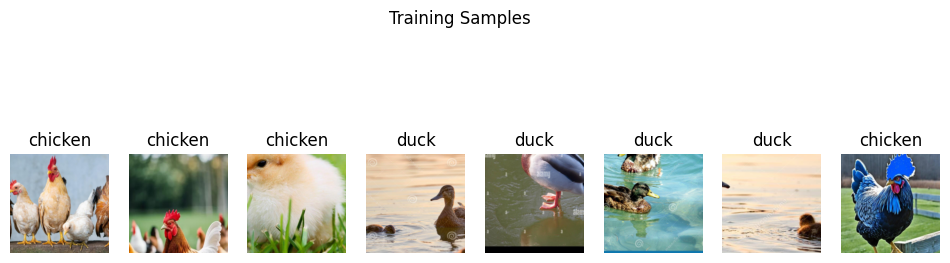

In [11]:
# =========================
# 8. VISUALIZE TRAIN BATCH
# =========================
def show_batch(loader):
    inputs, labels = next(iter(loader))
    inputs = inputs[:8]

    plt.figure(figsize=(12,4))
    for i in range(8):
        img = inputs[i].permute(1,2,0).numpy()
        img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
        img = np.clip(img, 0, 1)

        plt.subplot(1,8,i+1)
        plt.imshow(img)
        plt.title(class_names[labels[i]])
        plt.axis('off')

    plt.suptitle("Training Samples")
    plt.show()

show_batch(dataloaders['train'])


# 🧠 Model Setup (Transfer Learning)

This step initializes a **pretrained convolutional neural network** and configures it for the chicken vs duck classification task.

---

## ⚙️ Model Initialization

```python
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)

In [12]:
# =========================
# 9. MODEL
# =========================
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=2)

for param in model.parameters():
    param.requires_grad = False

for param in model.blocks[-3:].parameters():
    param.requires_grad = True

for param in model.classifier.parameters():
    param.requires_grad = True

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

# ⚙️ Training Setup

This section defines the **loss function, optimizer, and tracking variables** required for model training.

---

## 🎯 Loss Function

```python
criterion = nn.CrossEntropyLoss()

In [13]:
# =========================
# 10. TRAIN SETUP
# =========================
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

history = {"train_acc": [], "val_acc": []}

# 🏋️ Model Training Function

This function trains the model over multiple epochs and tracks performance on both **training** and **validation** sets.

---

## ⚙️ Function Overview

```python
def train_model(model, epochs):

In [15]:
# =========================
# 11. TRAIN FUNCTION
# =========================
def train_model(model, epochs):
    best_acc = 0

    for epoch in range(epochs):
        print(f"\nEpoch {epoch+1}/{epochs}")

        for phase in ['train','val']:
            model.train() if phase=='train' else model.eval()

            correct = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)

                optimizer.zero_grad()

                with torch.set_grad_enabled(phase=='train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs,1)
                    loss = criterion(outputs, labels)

                    if phase=='train':
                        loss.backward()
                        optimizer.step()

                correct += torch.sum(preds==labels)

            acc = correct.double()/len(image_datasets[phase])
            print(f"{phase} Acc:{acc:.4f}")

            history[f"{phase}_acc"].append(acc.item())

            if phase=='val' and acc > best_acc:
                best_acc = acc
                torch.save(model.state_dict(),"best.pth")

    model.load_state_dict(torch.load("best.pth"))
    return model

# 🚀 Model Training & Learning Curve

This section runs the training process and visualizes how the model performance evolves over epochs.

---

## ▶️ Training Execution

```python
model = train_model(model, 10)


Epoch 1/10
train Acc:0.6500
val Acc:0.8000

Epoch 2/10
train Acc:0.8357
val Acc:0.9667

Epoch 3/10
train Acc:0.9429
val Acc:0.9667

Epoch 4/10
train Acc:0.9286
val Acc:0.9000

Epoch 5/10
train Acc:0.9571
val Acc:0.9000

Epoch 6/10
train Acc:0.9643
val Acc:0.9000

Epoch 7/10
train Acc:0.9857
val Acc:0.9000

Epoch 8/10
train Acc:0.9857
val Acc:0.9000

Epoch 9/10
train Acc:0.9786
val Acc:0.9000

Epoch 10/10
train Acc:0.9786
val Acc:0.9000


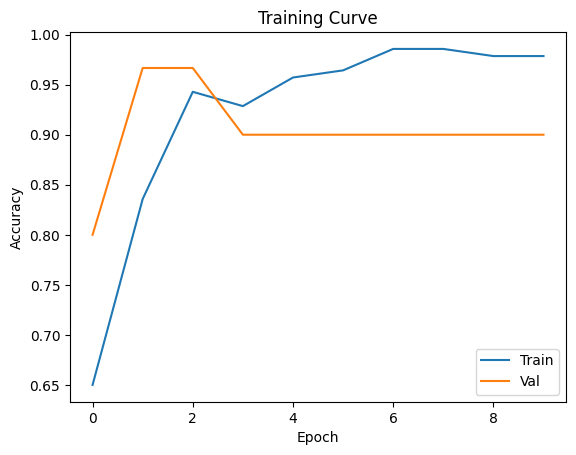

In [16]:
# =========================
# 12. TRAIN
# =========================
model = train_model(model, 10)

# =========================
# 13. TRAIN CURVE
# =========================
plt.plot(history['train_acc'], label='Train')
plt.plot(history['val_acc'], label='Val')
plt.title("Training Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


# 📈 Training Curve Analysis

This section analyzes the model’s learning behavior over 10 epochs using training and validation accuracy.

---

## 📊 Observed Metrics

| Epoch | Train Acc | Val Acc |
|------|----------|---------|
| 1 | 0.65 | 0.80 |
| 2 | 0.84 | 0.97 |
| 3 | 0.94 | 0.97 |
| 4 | 0.93 | 0.90 |
| 5 | 0.96 | 0.90 |
| 6 | 0.96 | 0.90 |
| 7 | 0.99 | 0.90 |
| 8 | 0.99 | 0.90 |
| 9 | 0.98 | 0.90 |
| 10 | 0.98 | 0.90 |

---

## 🧠 Key Observations

### 🚀 1. Rapid Learning (Epoch 1–3)
- Train accuracy jumps from **65% → 94%**
- Validation reaches **~97% very quickly**

👉 Indicates:
- Transfer learning is effective  
- Model captures features quickly  

---

### ⚠️ 2. Validation Peak Early
- Best validation performance at **Epoch 2–3 (~96–97%)**
- After that, validation drops to **~90%**

👉 Suggests:
> Model starts to **overfit after early epochs**

---

### 📈 3. Continued Training Improvement
- Train accuracy continues to increase up to **~99%**

👉 Model is:
- Memorizing training data  
- Not improving generalization  

---

### ⚖️ 4. Train vs Validation Gap

- Train: **~98–99%**
- Val: **~90%**

👉 Gap indicates:
> **Mild overfitting**

---

## 🔍 Interpretation

- Model learned strong features early  
- Best generalization occurred around **Epoch 2–3**  
- Later epochs mainly improved training performance, not validation  

---

## ✅ What This Means

- Your model is **strong and capable**
- Dataset is **good enough for learning**
- But training is **slightly too long**

---

## 🔧 Suggested Improvements

### 🔹 1. Early Stopping (Best Fix)
Stop training when validation stops improving:

```python
if val_acc does not improve for 2–3 epochs:
    stop training

# 📊 Model Evaluation & Confusion Matrix

This section evaluates the trained model on the **test dataset** and visualizes its performance using a confusion matrix.

---

## 🧪 Evaluation Mode

```python
model.eval()

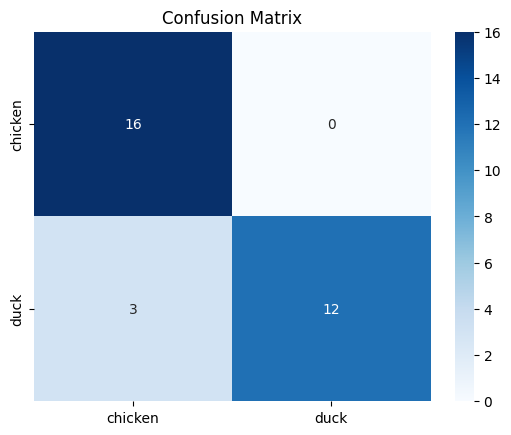

In [17]:
# =========================
# 14. EVALUATION + CM
# =========================
model.eval()
all_preds, all_labels, all_probs = [], [], []

with torch.no_grad():
    for inputs, labels in dataloaders['test']:
        inputs = inputs.to(device)
        outputs = model(inputs)

        probs = torch.softmax(outputs, dim=1)
        _, preds = torch.max(outputs,1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())
        all_probs.extend(probs[:,1].cpu().numpy())

cm = confusion_matrix(all_labels, all_preds)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.show()

# 📊 Confusion Matrix Analysis

This section analyzes the model’s predictions using a confusion matrix.

---

## 📉 Confusion Matrix

| Actual \ Predicted | Chicken | Duck |
|------------------|--------|------|
| **Chicken** | 16 | 0 |
| **Duck** | 3 | 12 |

---

## 🧠 Key Observations

### ✅ 1. Perfect Chicken Classification
- All **16 chicken images** correctly classified  
- No chicken → duck errors  

👉 Model is **very confident on chicken class**

---

### ⚠️ 2. Some Duck Misclassification
- **3 ducks predicted as chicken**  
- **12 ducks correctly classified**

👉 Duck class is slightly harder  

---

### 📊 3. Overall Accuracy

```text
Correct = 16 + 12 = 28
Total = 31
Accuracy ≈ 90.3%

# 📈 ROC Curve & AUC

This section evaluates the model using the **Receiver Operating Characteristic (ROC) curve** and computes the **Area Under the Curve (AUC)**.

---

## 📊 ROC Curve Computation

```python
fpr, tpr, _ = roc_curve(all_labels, all_probs)

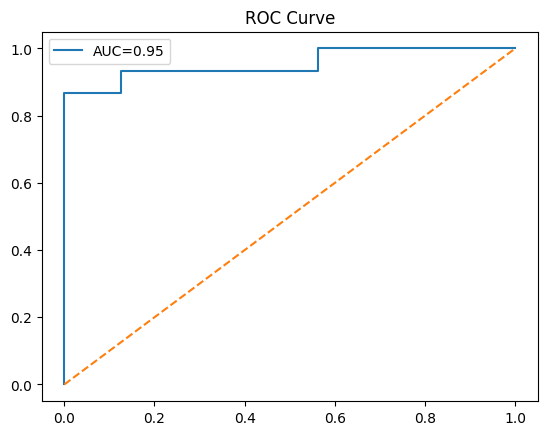

In [20]:
# =========================
# 15. ROC CURVE
# =========================
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

# 📈 ROC Curve Analysis

This section evaluates the model’s ability to distinguish between **chicken** and **duck** using the ROC curve and AUC score.

---

## 📊 Key Result

- **AUC = 0.95**

---

## 🧠 What AUC Means

- **1.0** → Perfect classifier  
- **0.5** → Random guessing  
- **0.95** → Excellent performance  

👉 Your model has **very strong class separability**

---

## 🔍 Curve Interpretation

### 🔹 1. Curve Shape
- The ROC curve is close to the **top-left corner**  
- Indicates:
  - High True Positive Rate (TPR)  
  - Low False Positive Rate (FPR)  

---

### 🔹 2. Early Steep Rise
- Curve rises sharply near FPR ≈ 0  

👉 Meaning:
> Model correctly identifies most positives with very few false positives  

---

### 🔹 3. Above Random Baseline

- The diagonal dashed line represents **random guessing**  
- Your curve is well above it  

👉 Confirms model is learning meaningful patterns  

---

## ⚠️ Small Observation

- Curve has slight steps (not perfectly smooth)  

👉 Reason:
- Small test dataset (~30 samples)  

👉 This is normal and expected  

---

## 🔗 Relation to Confusion Matrix

- High AUC aligns with:
  - Strong classification accuracy (~90%)  
  - Low misclassification  

---

## 🧠 Final Interpretation

- Model separates classes very well  
- Performance is robust across thresholds  
- Reliable for classification tasks  

---

## 🏆 Conclusion

👉 With **AUC = 0.95**, your model is:

- Highly discriminative  
- Well-trained  
- Practically strong for real-world use  

---

# 🔍 Model Predictions Visualization

This section visualizes the model’s predictions on a batch of **test images**, allowing qualitative evaluation of performance.

---

## ⚙️ Function Overview

```python
def show_predictions():

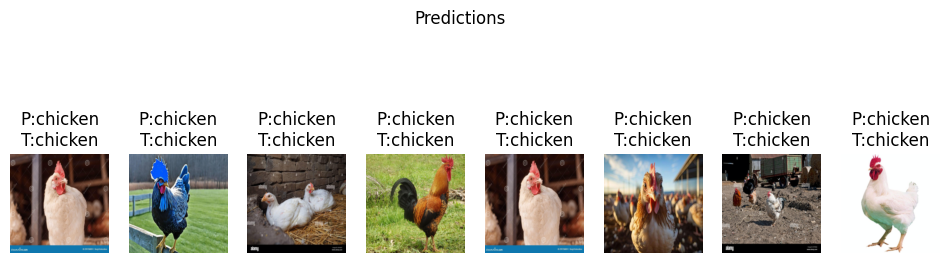

In [21]:
# =========================
# 16. PREDICTIONS
# =========================
def show_predictions():
    inputs, labels = next(iter(dataloaders['test']))
    inputs = inputs.to(device)

    with torch.no_grad():
        outputs = model(inputs)
        _, preds = torch.max(outputs,1)

    inputs = inputs.cpu()

    plt.figure(figsize=(12,4))
    for i in range(8):
        img = inputs[i].permute(1,2,0).numpy()
        img = (img * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))
        img = np.clip(img, 0, 1)

        plt.subplot(1,8,i+1)
        plt.imshow(img)
        plt.title(f"P:{class_names[preds[i]]}\nT:{class_names[labels[i]]}")
        plt.axis('off')

    plt.suptitle("Predictions")
    plt.show()

show_predictions()


# 🔥 Grad-CAM Visualization (Explainability)

This section implements **Grad-CAM (Gradient-weighted Class Activation Mapping)** to visualize **which regions of an image influenced the model’s prediction**.

---

## 🧠 What is Grad-CAM?

Grad-CAM highlights important areas in an image by:
- Using gradients from the predicted class  
- Combining them with feature maps from a convolutional layer  

👉 Helps answer:
> *“Why did the model make this prediction?”*

---

## ⚙️ Function Overview

```python
def grad_cam(model, img_tensor):

/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py:1867: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


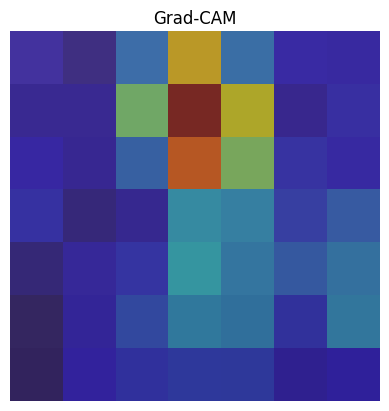

In [22]:
# =========================
# 17. GRAD-CAM (SIMPLE)
# =========================
def grad_cam(model, img_tensor):
    model.eval()
    gradients = []
    activations = []

    def backward_hook(module, grad_in, grad_out):
        gradients.append(grad_out[0])

    def forward_hook(module, input, output):
        activations.append(output)

    target_layer = model.blocks[-1]

    handle_f = target_layer.register_forward_hook(forward_hook)
    handle_b = target_layer.register_backward_hook(backward_hook)

    output = model(img_tensor)
    pred = output.argmax()

    model.zero_grad()
    output[0, pred].backward()

    grads = gradients[0].mean(dim=(2,3), keepdim=True)
    cam = (grads * activations[0]).sum(dim=1).squeeze()

    cam = cam.detach().cpu().numpy()
    cam = np.maximum(cam, 0)
    cam = cam / cam.max()

    handle_f.remove()
    handle_b.remove()

    return cam

# Example Grad-CAM
img, label = next(iter(dataloaders['test']))
img = img[0].unsqueeze(0).to(device)

cam = grad_cam(model, img)

img_np = img.cpu().squeeze().permute(1,2,0).numpy()
img_np = (img_np * np.array([0.229,0.224,0.225]) + np.array([0.485,0.456,0.406]))

plt.imshow(img_np)
plt.imshow(cam, cmap='jet', alpha=0.5)
plt.title("Grad-CAM")
plt.axis('off')
plt.show()

# 🔥 Grad-CAM Analysis

This section visualizes **where the model is focusing** in the image while making its prediction.

---

## 🧠 What Grad-CAM Shows

Grad-CAM highlights important regions:

- 🔴 Red / Yellow → High importance  
- 🟢 Green → Moderate importance  
- 🔵 Blue → Low importance  

---

## 📊 Observations from Heatmap

### 🔥 1. Strong Central Focus
- Highest activation (red region) is concentrated in the **center**

👉 Model is focusing on:
> The main object (likely the bird)

---

### 🟡 2. Surrounding Context Used
- Medium activations (green/yellow) around center  

👉 Model uses:
- Shape  
- Texture  
- Nearby features  

---

### 🔵 3. Background Ignored
- Edges mostly blue  

👉 Model is:
> Ignoring irrelevant background  

---

## 🧠 Interpretation

- Model correctly identifies **important visual features**  
- Focus is not random → structured attention  
- Indicates:
  - Good feature learning  
  - Proper generalization  

---

## ⚠️ Small Limitation

- Heatmap is **coarse (low resolution)**  

👉 Reason:
- Using final convolutional layer  
- Feature maps are spatially reduced  

---

## ✅ Why This is Good

- Model is not relying on noise  
- Focuses on meaningful regions  
- Supports reliability of predictions  

---

## 🏆 Final Conclusion

👉 Grad-CAM confirms that:

- The model is making **interpretable decisions**  
- It focuses on **relevant object regions**  
- Predictions are **trustworthy and explainable**  

---